## [41]: データを読み込み利用データを整形する

In [1]:
import pandas as pd

In [2]:
customer = pd.read_csv("customer_join.csv")
uselog_months = pd.read_csv("use_log_months.csv")

In [3]:
year_months = list(uselog_months["年月"].unique()) # 年月のユニークな値を取得
uselog = pd.DataFrame() # 空のDataFrameを作成

for i in range(1, len(year_months)): # 1からユニークな年月の数までループ
    tmp = uselog_months.loc[uselog_months["年月"] == year_months[i]].copy() # 年月が一致する行をtmpにコピー
    tmp.rename(columns = {"count": "count_0"}, inplace = True) # 列名を変更
    tmp_before = uselog_months.loc[uselog_months["年月"] == year_months[i - 1]].copy() # 前の年月の行をtmp_beforeにコピー
    del tmp_before["年月"] # 年月列を削除
    tmp_before.rename(columns = {"count": "count_1"}, inplace = True) # 列名を変更
    tmp = pd.merge(tmp, tmp_before, on = "customer_id", how = "left") # tmpとtmp_beforeをcustomer_idで結合
    uselog = pd.concat([uselog, tmp], ignore_index = True) # uselogにtmpを追加

uselog.head()

,年月,customer_id,count_0,count_1
0,201805,AS002855,5,4.0
1,201805,AS009373,4,3.0
2,201805,AS015233,7,NaN
3,201805,AS015315,3,6.0
4,201805,AS015739,5,7.0


## [42]: 退会前月の退会顧客データを作成する

In [4]:
from dateutil.relativedelta import relativedelta

exit_customer = customer.loc[customer["is_deleted"] == 1].copy() # is_deletedが1の行をコピー
exit_customer["exit_date"] = None # exit_date列を追加
exit_customer["end_date"] = pd.to_datetime(exit_customer["end_date"]) # end_dateをdatetime型に変換

for i in exit_customer.index: # exit_customerのインデックスでループ
    exit_customer.loc[i, "exit_date"] = exit_customer.loc[i, "end_date"] - relativedelta(months = 1) # end_dateから1ヶ月を引く

exit_customer["exit_date"] = pd.to_datetime(exit_customer["exit_date"]) # exit_dateをdatetime型に変換
exit_customer["年月"] = exit_customer["exit_date"].dt.strftime("%Y%m") # exit_dateを年月形式に変換

uselog["年月"] = uselog["年月"].astype(str) # uselogの年月を文字列型に変換
exit_uselog = pd.merge(uselog, exit_customer, on = ["customer_id", "年月"], how = "left") # uselogとexit_customerを結合

print(len(uselog)) # uselogの行数を表示
exit_uselog.head() # 結合結果を表示

33851


,年月,customer_id,count_0,count_1,name,class,gender,start_date,end_date,campaign_id,...,price,campaign_name,mean,median,max,min,routine_flg,calc_date,membership_period,exit_date
0,201805,AS002855,5,4.0,NaN,NaN,NaN,NaN,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,201805,AS009373,4,3.0,NaN,NaN,NaN,NaN,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,201805,AS015233,7,NaN,NaN,NaN,NaN,NaN,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,201805,AS015315,3,6.0,NaN,NaN,NaN,NaN,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,201805,AS015739,5,7.0,NaN,NaN,NaN,NaN,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [5]:
exit_uselog = exit_uselog.dropna(subset = ["name"]) # name列がNaNの行を削除
print(len(exit_uselog)) # 削除後の行数を表示
print(len(exit_uselog["customer_id"].unique())) # ユニークなcustomer_idの数を表示
exit_uselog.head()

1104
1104


,年月,customer_id,count_0,count_1,name,class,gender,start_date,end_date,campaign_id,...,price,campaign_name,mean,median,max,min,routine_flg,calc_date,membership_period,exit_date
19,201805,AS055680,3,3.0,XXXXX,C01,M,2018-03-01,2018-06-30,CA1,...,10500.0,通常,3.000000,3.0,3.0,3.0,0.0,2018-06-30,3.0,2018-05-30
57,201805,AS169823,2,3.0,XX,C01,M,2017-11-01,2018-06-30,CA1,...,10500.0,通常,3.000000,3.0,4.0,2.0,1.0,2018-06-30,7.0,2018-05-30
110,201805,AS305860,5,3.0,XXXX,C01,M,2017-06-01,2018-06-30,CA1,...,10500.0,通常,3.333333,3.0,5.0,2.0,0.0,2018-06-30,12.0,2018-05-30
128,201805,AS363699,5,3.0,XXXXX,C01,M,2018-02-01,2018-06-30,CA1,...,10500.0,通常,3.333333,3.0,5.0,2.0,0.0,2018-06-30,4.0,2018-05-30
147,201805,AS417696,1,4.0,XX,C03,F,2017-09-01,2018-06-30,CA1,...,6000.0,通常,2.000000,1.0,4.0,1.0,0.0,2018-06-30,9.0,2018-05-30


## [43]: 継続顧客データを作成する

In [6]:
conti_customer = customer.loc[customer["is_deleted"] == 0] # is_deletedが0の行を取得
conti_uselog = pd.merge(uselog, conti_customer, on = ["customer_id"], how = "left") # uselogとconti_customerを結合

print(len(conti_uselog)) # conti_uselogの行数を表示
conti_uselog = conti_uselog.dropna(subset = ["name"]) # name列がNaNの行を削除
print(len(conti_uselog)) # 削除後の行数を表示

33851
27422


`.loc`は、PandasライブラリのDataFrameやSeriesで使用されるインデックス参照メソッドです。行や列をラベル（名前）や条件を指定して取得・操作するために使われます。

### 主な特徴
1. **ラベルベースのインデックス参照**  
   行や列をラベル（名前）で指定してデータを取得します。

2. **条件を指定してフィルタリング**  
   条件式を使って特定の行を抽出できます。

3. **データの取得・更新**  
   データの取得だけでなく、値の更新や新しい列の追加も可能です。



In [7]:
conti_uselog = conti_uselog.sample(frac = 1, random_state = 0).reset_index(drop = True) # conti_uselogをシャッフル
 # customer_idで重複を削除

print(len(conti_uselog)) # 重複削除後の行数を表示
conti_uselog.head()

27422


,年月,customer_id,count_0,count_1,name,class,gender,start_date,end_date,campaign_id,...,class_name,price,campaign_name,mean,median,max,min,routine_flg,calc_date,membership_period
0,201806,AS015233,7,7.0,XXXXX,C01,M,2018-05-13,NaN,CA2,...,オールタイム,10500.0,入会費半額,7.545455,7.0,11.0,4.0,1.0,2019-04-30,11.0
1,201812,AS046594,7,5.0,XXX,C01,M,2018-03-01,NaN,CA1,...,オールタイム,10500.0,通常,7.166667,7.0,10.0,5.0,1.0,2019-04-30,13.0
2,201808,OA769163,6,4.0,XXX,C01,M,2017-05-01,NaN,CA1,...,オールタイム,10500.0,通常,6.083333,6.0,8.0,2.0,1.0,2019-04-30,23.0
3,201805,AS981537,10,6.0,XX,C03,M,2018-02-01,NaN,CA1,...,ナイト,6000.0,通常,6.916667,7.0,10.0,5.0,1.0,2019-04-30,14.0
4,201805,GD065188,6,7.0,XX,C01,M,2017-09-01,NaN,CA1,...,オールタイム,10500.0,通常,6.333333,6.5,9.0,3.0,1.0,2019-04-30,19.0


以下のコードが行っている処理を順番に説明します：

```python
conti_uselog = conti_uselog.sample(frac = 1, random_state = 0).reset_index(drop = True)
```

### 1. **`sample(frac=1)`**
- `sample`メソッドは、DataFrameの行をランダムにサンプリングするために使用されます。
- `frac=1`は、元のDataFrame全体（100%）をランダムに並び替えることを意味します。  
  → **つまり、DataFrame全体をシャッフルします。**

### 2. **`random_state=0`**
- `random_state`は、乱数のシード値を指定します。
- 同じシード値を指定すると、毎回同じ順序でシャッフルされます。  
  → **結果を再現可能にするための設定です。**

### 3. **`reset_index(drop=True)`**
- シャッフル後のDataFrameのインデックスをリセットします。
- `drop=True`を指定することで、元のインデックスを新しいDataFrameに追加せず、単純にリセットします。  
  → **インデックスが0から始まる連番にリセットされます。**

---

### 全体の処理
1. `conti_uselog`の行をランダムに並び替える（シャッフル）。
2. シャッフル後のインデックスをリセットし、元のインデックスを削除する。

---

### 実行例
```python
import pandas as pd

# サンプルデータ
data = {'customer_id': [1, 2, 3, 4, 5], 'value': [10, 20, 30, 40, 50]}
conti_uselog = pd.DataFrame(data)

# シャッフルとインデックスリセット
conti_uselog = conti_uselog.sample(frac=1, random_state=0).reset_index(drop=True)
print(conti_uselog)
```

#### 実行結果
```plaintext
   customer_id  value
0            5     50
1            1     10
2            4     40
3            2     20
4            3     30
```

このように、行がランダムに並び替えられ、インデックスがリセットされています。

以下のコードについて説明します：

```python
conti_uselog = conti_uselog.drop_duplicates(subset="customer_id")
```

### このコードが行う処理
1. **`drop_duplicates`メソッド**  
   - Pandasの`drop_duplicates`メソッドは、DataFrameから重複した行を削除するために使用されます。

2. **`subset="customer_id"`**  
   - `subset`引数で、重複を判定する基準となる列を指定します。
   - この場合、`customer_id`列を基準にして、同じ`customer_id`を持つ行のうち最初の1行だけを残し、それ以外の重複行を削除します。

3. **結果の代入**  
   - 重複を削除した新しいDataFrameを`conti_uselog`に再代入しています。

---

### 処理の流れ
1. `customer_id`列を基準に、同じ値を持つ行を探します。
2. 最初に見つかった行を残し、それ以外の重複行を削除します。

---

### 実行例
```python
import pandas as pd

# サンプルデータ
data = {
    'customer_id': [1, 2, 2, 3, 4, 4],
    'value': [10, 20, 30, 40, 50, 60]
}
conti_uselog = pd.DataFrame(data)

# 重複削除
conti_uselog = conti_uselog.drop_duplicates(subset="customer_id")
print(conti_uselog)
```

#### 実行結果
```plaintext
   customer_id  value
0            1     10
1            2     20
3            3     40
4            4     50
```

---

### 注意点
- `drop_duplicates`は、デフォルトで最初に見つかった行を残しますが、`keep="last"`を指定すると最後の行を残すこともできます。
- 元のDataFrameを変更せずに結果を確認したい場合は、`inplace=False`（デフォルト）を利用します。

---

### あなたのコードでの意図
このコードでは、`conti_uselog`内で同じ`customer_id`を持つ行が複数存在する場合に、重複を削除して1つだけ残すことで、顧客ごとに一意なデータを保持しようとしています。

In [8]:
predict_data = pd.concat([conti_uselog, exit_uselog], ignore_index = True) # conti_uselogとexit_uselogを結合

print(len(predict_data))
predict_data.head() # 結合結果を表示

28526


C:\Users\seiya\AppData\Local\Temp\ipykernel_18968\861107030.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  predict_data = pd.concat([conti_uselog, exit_uselog], ignore_index = True) # conti_uselogとexit_uselogを結合


,年月,customer_id,count_0,count_1,name,class,gender,start_date,end_date,campaign_id,...,price,campaign_name,mean,median,max,min,routine_flg,calc_date,membership_period,exit_date
0,201806,AS015233,7,7.0,XXXXX,C01,M,2018-05-13,NaT,CA2,...,10500.0,入会費半額,7.545455,7.0,11.0,4.0,1.0,2019-04-30,11.0,NaT
1,201812,AS046594,7,5.0,XXX,C01,M,2018-03-01,NaT,CA1,...,10500.0,通常,7.166667,7.0,10.0,5.0,1.0,2019-04-30,13.0,NaT
2,201808,OA769163,6,4.0,XXX,C01,M,2017-05-01,NaT,CA1,...,10500.0,通常,6.083333,6.0,8.0,2.0,1.0,2019-04-30,23.0,NaT
3,201805,AS981537,10,6.0,XX,C03,M,2018-02-01,NaT,CA1,...,6000.0,通常,6.916667,7.0,10.0,5.0,1.0,2019-04-30,14.0,NaT
4,201805,GD065188,6,7.0,XX,C01,M,2017-09-01,NaT,CA1,...,10500.0,通常,6.333333,6.5,9.0,3.0,1.0,2019-04-30,19.0,NaT


## [44]: 予測する月の在籍期間を作成する

In [9]:
predict_data["period"] = 0 # period列を追加
predict_data["now_date"] = pd.to_datetime(predict_data["年月"], format = "%Y%m") # 年月をdatetime型に変換
predict_data["start_date"] = pd.to_datetime(predict_data["start_date"]) # start_dateをdatetime型に変換

for i in range(len(predict_data)): # predict_dataの行数分ループ
    delta = relativedelta(predict_data.loc[i, "now_date"], predict_data.loc[i, "start_date"]) # now_dateとstart_dateの差を計算
    predict_data.loc[i, "period"] = int(delta.years * 12 + delta.months) # 年と月を合計してperiodに代入

predict_data.head()

,年月,customer_id,count_0,count_1,name,class,gender,start_date,end_date,campaign_id,...,mean,median,max,min,routine_flg,calc_date,membership_period,exit_date,period,now_date
0,201806,AS015233,7,7.0,XXXXX,C01,M,2018-05-13,NaT,CA2,...,7.545455,7.0,11.0,4.0,1.0,2019-04-30,11.0,NaT,0,2018-06-01
1,201812,AS046594,7,5.0,XXX,C01,M,2018-03-01,NaT,CA1,...,7.166667,7.0,10.0,5.0,1.0,2019-04-30,13.0,NaT,9,2018-12-01
2,201808,OA769163,6,4.0,XXX,C01,M,2017-05-01,NaT,CA1,...,6.083333,6.0,8.0,2.0,1.0,2019-04-30,23.0,NaT,15,2018-08-01
3,201805,AS981537,10,6.0,XX,C03,M,2018-02-01,NaT,CA1,...,6.916667,7.0,10.0,5.0,1.0,2019-04-30,14.0,NaT,3,2018-05-01
4,201805,GD065188,6,7.0,XX,C01,M,2017-09-01,NaT,CA1,...,6.333333,6.5,9.0,3.0,1.0,2019-04-30,19.0,NaT,8,2018-05-01


## [45]: 欠損値を除去する

In [10]:
predict_data.isna().sum() # NaNの数を表示

年月                       0
customer_id              0
count_0                  0
count_1                740
name                     0
class                    0
gender                   0
start_date               0
end_date             27422
campaign_id              0
is_deleted               0
class_name               0
price                    0
campaign_name            0
mean                     0
median                   0
max                      0
min                      0
routine_flg              0
calc_date                0
membership_period        0
exit_date            27422
period                   0
now_date                 0
dtype: int64

In [11]:
predict_data = predict_data.dropna(subset = ["count_1"]) # count_1列がNaNの行を削除
predict_data.isna().sum() # NaNの数を表示

年月                       0
customer_id              0
count_0                  0
count_1                  0
name                     0
class                    0
gender                   0
start_date               0
end_date             26734
campaign_id              0
is_deleted               0
class_name               0
price                    0
campaign_name            0
mean                     0
median                   0
max                      0
min                      0
routine_flg              0
calc_date                0
membership_period        0
exit_date            26734
period                   0
now_date                 0
dtype: int64

## [46]: 文字列型の変数を処理できるように整形する

In [12]:
target_col = ["campaign_name", "class_name", "gender", "count_1", "routine_flg", "period", "is_deleted"] # ターゲット列を指定
predict_data = predict_data[target_col] # ターゲット列を抽出
predict_data.head()

,campaign_name,class_name,gender,count_1,routine_flg,period,is_deleted
0,入会費半額,オールタイム,M,7.0,1.0,0,0.0
1,通常,オールタイム,M,5.0,1.0,9,0.0
2,通常,オールタイム,M,4.0,1.0,15,0.0
3,通常,ナイト,M,6.0,1.0,3,0.0
4,通常,オールタイム,M,7.0,1.0,8,0.0


In [13]:
predict_data = pd.get_dummies(predict_data) # ダミー変数化
predict_data.head() # ダミー変数化したデータを表示

,count_1,routine_flg,period,is_deleted,campaign_name_入会費半額,campaign_name_入会費無料,campaign_name_通常,class_name_オールタイム,class_name_デイタイム,class_name_ナイト,gender_F,gender_M
0,7.0,1.0,0,0.0,True,False,False,True,False,False,False,True
1,5.0,1.0,9,0.0,False,False,True,True,False,False,False,True
2,4.0,1.0,15,0.0,False,False,True,True,False,False,False,True
3,6.0,1.0,3,0.0,False,False,True,False,False,True,False,True
4,7.0,1.0,8,0.0,False,False,True,True,False,False,False,True


In [14]:
del predict_data["campaign_name_通常"] # 不要な列を削除
del predict_data["class_name_ナイト"] # 不要な列を削除
del predict_data["gender_M"] # 不要な列を削除

predict_data.head()

,count_1,routine_flg,period,is_deleted,campaign_name_入会費半額,campaign_name_入会費無料,class_name_オールタイム,class_name_デイタイム,gender_F
0,7.0,1.0,0,0.0,True,False,True,False,False
1,5.0,1.0,9,0.0,False,False,True,False,False
2,4.0,1.0,15,0.0,False,False,True,False,False
3,6.0,1.0,3,0.0,False,False,False,False,False
4,7.0,1.0,8,0.0,False,False,True,False,False


## [47]: 決定木を用いて退会予測モデルを作成する

In [15]:
from sklearn.tree import DecisionTreeClassifier # 決定木分類器をインポート
import sklearn.model_selection # モデル選択モジュールをインポート


exit = predict_data.loc[predict_data["is_deleted"] == 1] # is_deletedが1の行を抽出
conti = predict_data.loc[predict_data["is_deleted"] == 0].sample(len(exit), random_state = 0) # is_deletedが0の行を抽出し、exitと同じ数だけサンプリング

X = pd.concat([exit, conti], ignore_index = True) # exitとcontiを結合
y = X["is_deleted"] # 目的変数を指定
del X["is_deleted"] # 目的変数を削除
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, random_state = 0) # データを分割

model = DecisionTreeClassifier(random_state = 0) # 決定木分類器をインスタンス化
model.fit(X_train, y_train) # モデルを学習
y_test_pred = model.predict(X_test) # テストデータで予測
print(y_test_pred) # 予測結果を表示

[0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1.
 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1.
 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1.
 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1.
 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1.

以下のコードは、PandasとScikit-learnを使用して、退会予測モデルを作成するプロセスを示しています。コードの各部分を順番に説明します。

---

### 1. **必要なライブラリのインポート**
```python
from sklearn.tree import DecisionTreeClassifier # 決定木分類器をインポート
import sklearn.model_selection # モデル選択モジュールをインポート
```
- **`DecisionTreeClassifier`**: 決定木アルゴリズムを使用して分類モデルを作成するためのクラス。
- **`sklearn.model_selection`**: データを訓練データとテストデータに分割するためのモジュール。

---

### 2. **退会顧客データと継続顧客データの準備**
```python
exit = predict_data.loc[predict_data["is_deleted"] == 1] # is_deletedが1の行を抽出
conti = predict_data.loc[predict_data["is_deleted"] == 0].sample(len(exit), random_state = 0) # is_deletedが0の行を抽出し、exitと同じ数だけサンプリング
```
- **`predict_data`**: 予測に使用するデータセット。
- **`is_deleted`**: 顧客が退会したかどうかを示す列（1: 退会、0: 継続）。
- **`exit`**: `is_deleted`が1の行（退会顧客）を抽出。
- **`conti`**: `is_deleted`が0の行（継続顧客）を抽出し、退会顧客と同じ数だけランダムにサンプリング。
  - **`sample(len(exit))`**: 退会顧客の数に合わせて継続顧客をランダムに選択。
  - **`random_state=0`**: サンプリングの結果を再現可能にするための乱数シード。

---

### 3. **データの結合と目的変数の分離**
```python
X = pd.concat([exit, conti], ignore_index = True) # exitとcontiを結合
y = X["is_deleted"] # 目的変数を指定
del X["is_deleted"] # 目的変数を削除
```
- **`pd.concat`**: 退会顧客データ（`exit`）と継続顧客データ（`conti`）を結合して1つのデータセット（`X`）を作成。
- **`y`**: 目的変数（ラベル）として`is_deleted`列を抽出。
- **`del X["is_deleted"]`**: 特徴量データ（`X`）から目的変数（`is_deleted`列）を削除。

---

### 4. **データの分割**
```python
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, random_state = 0) # データを分割
```
- **`train_test_split`**: データを訓練データ（`X_train`, `y_train`）とテストデータ（`X_test`, `y_test`）に分割。
  - **`X_train`**: モデルの学習に使用する特徴量データ。
  - **`y_train`**: モデルの学習に使用するラベルデータ。
  - **`X_test`**: モデルの評価に使用する特徴量データ。
  - **`y_test`**: モデルの評価に使用するラベルデータ。
- **`random_state=0`**: データ分割の結果を再現可能にするための乱数シード。

---

### 5. **モデルの作成と学習**
```python
model = DecisionTreeClassifier(random_state = 0) # 決定木分類器をインスタンス化
model.fit(X_train, y_train) # モデルを学習
```
- **`DecisionTreeClassifier`**: 決定木アルゴリズムを使用した分類モデルを作成。
  - **`random_state=0`**: 決定木の構造を再現可能にするための乱数シード。
- **`fit(X_train, y_train)`**: 訓練データ（`X_train`と`y_train`）を使用してモデルを学習。

---

### 6. **テストデータで予測**
```python
y_test_pred = model.predict(X_test) # テストデータで予測
print(y_test_pred) # 予測結果を表示
```
- **`predict(X_test)`**: 学習済みモデルを使用して、テストデータ（`X_test`）のラベルを予測。
- **`y_test_pred`**: テストデータに対する予測結果（退会か継続かを示すラベル）。
- **`print(y_test_pred)`**: 予測結果を出力。

---

### 全体の処理の流れ
1. データセットから退会顧客と継続顧客を抽出。
2. 継続顧客を退会顧客と同じ数だけランダムにサンプリング。
3. 退会顧客と継続顧客を結合し、目的変数（`is_deleted`）を分離。
4. データを訓練データとテストデータに分割。
5. 決定木モデルを作成し、訓練データで学習。
6. テストデータを使用して予測を行い、結果を出力。

---

### 注意点
- **バランスの取れたデータ**: 継続顧客を退会顧客と同じ数にサンプリングすることで、クラスの不均衡を解消しています。
- **再現性**: `random_state`を指定することで、結果を再現可能にしています。
- **モデルの評価**: このコードでは予測結果を出力していますが、精度やF1スコアなどの評価指標を計算することで、モデルの性能を確認することが推奨されます。

In [17]:
results_test = pd.DataFrame({"y_test": y_test, "y_pred": y_test_pred}) # テストデータの結果をDataFrameに格納
results_test.head() # テストデータの結果を表示

,y_test,y_pred
1091,0.0,0.0
1786,0.0,0.0
1439,0.0,0.0
745,1.0,1.0
820,1.0,0.0


## [48]: 予測モデルの評価を行い、モデルのチューニングをする

In [18]:
correct = len(results_test.loc[results_test["y_test"] == results_test["y_pred"]]) # 正解数をカウント
data_count = len(results_test) # データ数をカウント
score_test = correct / data_count # スコアを計算

print(score_test) # スコアを表示

0.9068441064638784


In [19]:
print(model.score(X_test, y_test)) # モデルのスコアを表示
print(model.score(X_train, y_train)) # モデルのスコアを表示

0.9068441064638784
0.9847908745247148


In [20]:
X = pd.concat([exit, conti], ignore_index = True) # exitとcontiを結合
y = X["is_deleted"] # 目的変数を指定
del X["is_deleted"] # 目的変数を削除
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, random_state = 0) # データを分割


model = DecisionTreeClassifier(random_state = 0, max_depth = 5) # 決定木分類器をインスタンス化
model.fit(X_train, y_train) # モデルを学習
print(model.score(X_test, y_test)) # モデルのスコアを表示
print(model.score(X_train, y_train)) # モデルのスコアを表示

0.9334600760456274
0.926489226869455


## [49]: モデルに寄与している変数を確認する

In [ ]:
importance = pd.DataFrame({"feature": X.columns, "conefficient": model.feature_importances_}) # 特徴量の重要度をDataFrameに格納
importance 

,feature,conefficient
0,count_1,0.270450
1,routine_flg,0.110875
2,period,0.616268
3,campaign_name_入会費半額,0.002407
4,campaign_name_入会費無料,0.000000
5,class_name_オールタイム,0.000000
6,class_name_デイタイム,0.000000
7,gender_F,0.000000


[Text(0.5643939393939394, 0.9166666666666666, 'period <= 11.5\ngini = 0.5\nsamples = 1578\nvalue = [792.0, 786.0]'),
 Text(0.26515151515151514, 0.75, 'count_1 <= 5.5\ngini = 0.327\nsamples = 880\nvalue = [181, 699]'),
 Text(0.4147727272727273, 0.8333333333333333, 'True  '),
 Text(0.12121212121212122, 0.5833333333333334, 'count_1 <= 4.5\ngini = 0.062\nsamples = 593\nvalue = [19, 574]'),
 Text(0.06060606060606061, 0.4166666666666667, 'count_1 <= 3.5\ngini = 0.02\nsamples = 497\nvalue = [5, 492]'),
 Text(0.030303030303030304, 0.25, 'gini = 0.0\nsamples = 359\nvalue = [0, 359]'),
 Text(0.09090909090909091, 0.25, 'period <= 9.5\ngini = 0.07\nsamples = 138\nvalue = [5, 133]'),
 Text(0.06060606060606061, 0.08333333333333333, 'gini = 0.036\nsamples = 110\nvalue = [2, 108]'),
 Text(0.12121212121212122, 0.08333333333333333, 'gini = 0.191\nsamples = 28\nvalue = [3, 25]'),
 Text(0.18181818181818182, 0.4166666666666667, 'routine_flg <= 0.5\ngini = 0.249\nsamples = 96\nvalue = [14, 82]'),
 Text(0.15

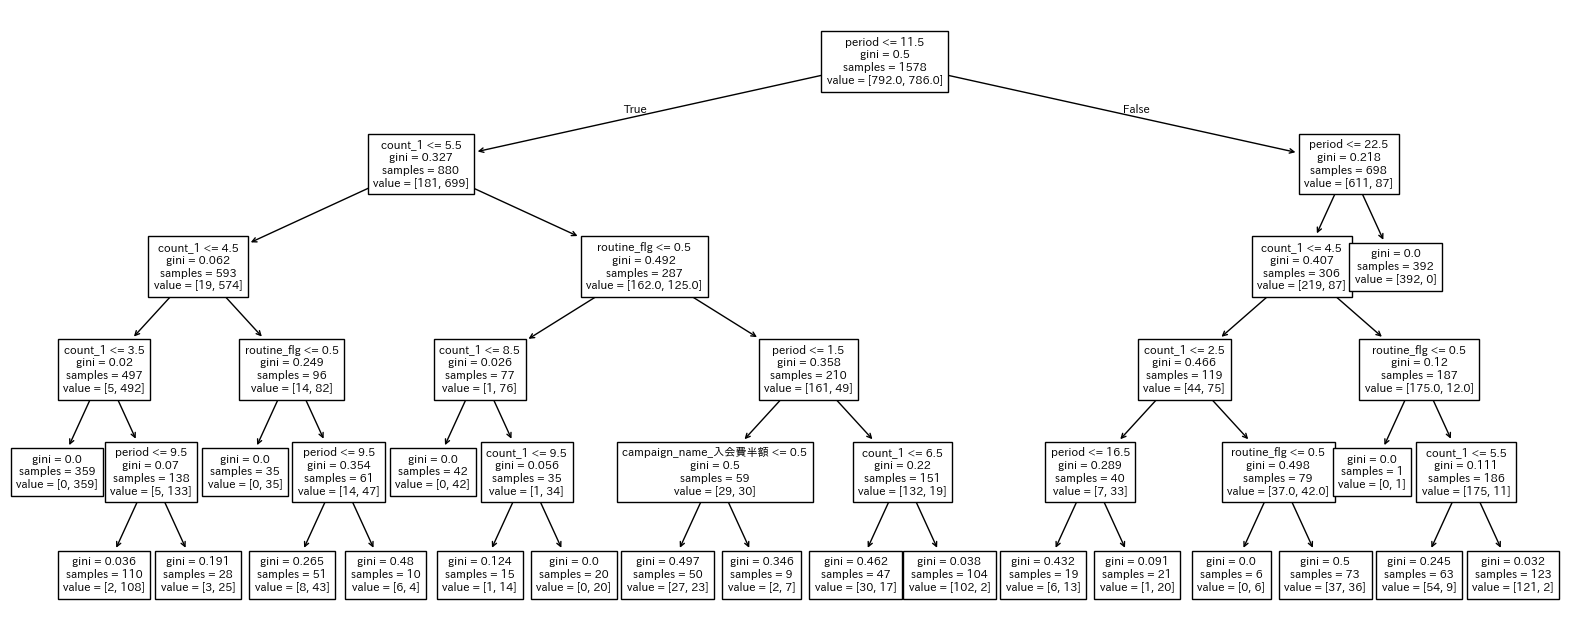

In [22]:
from sklearn import  tree # 決定木をインポート
import matplotlib.pyplot as plt # グラフ描画ライブラリをインポート
import japanize_matplotlib # 日本語フォントをインポート


plt.figure(figsize = (20, 8)) # グラフのサイズを指定
tree.plot_tree(model, feature_names = X.columns, fontsize = 8)# 決定木を描画


## [50]: 顧客の退会を予測する

In [24]:
count_1 = 3 # count_1の値を指定
routine_flg = 1 # routine_flgの値を指定
period = 10 # periodの値を指定
campaign_name = "入会費無料" # campaign_nameの値を指定
class_name = "オールタイム" # class_nameの値を指定
gender = "M" 

In [25]:
if campaign_name == "入会費半額":  # campaign_nameの値によってダミー変数を指定
    campaign_name_list = [1, 0] # ダミー変数を指定
elif campaign_name == "入会費無料": # campaign_nameの値によってダミー変数を指定
    campaign_name_list = [0, 1] # ダミー変数を指定
elif campaign_name == "通常": # campaign_nameの値によってダミー変数を指定
    campaign_name_list = [0, 0]


if class_name == "オールタイム": # class_nameの値によってダミー変数を指定
    class_name_list = [1, 0] # ダミー変数を指定
elif class_name == "デイタイム":
    class_name_list = [0, 1]
elif class_name == "ナイト":
    class_name_list = [0, 0]


if gender == "F": 
    gender_list = [1]
elif gender == "M":
    gender_list = [0]


input_data = [count_1, routine_flg, period] # 入力データを指定
input_data.extend(campaign_name_list) # campaign_nameのダミー変数を追加
input_data.extend(class_name_list) # class_nameのダミー変数を追加
input_data.extend(gender_list) 
input_data = pd.DataFrame(data = [input_data], columns = X.columns) # 入力データをDataFrameに変換

In [26]:
print(model.predict(input_data)) # 予測結果を表示
print(model.predict_proba(input_data)) # 予測確率を表示

[1.]
[[0. 1.]]
